In [278]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.constants as K
from scipy.optimize import curve_fit
import scipy.stats as stats
import sympy as sp

# LaTeX font
plt.style.use('default')
plt.rc('text', usetex = True)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
font_size = 20
plt.rcParams['font.size'] = font_size



## Header to .txt file

EVERYTHING IS IN THE OBSERVER FRAME

x		er_x			y		        er_y               y_model (not needed)

keV		keV			keV/(cm2 s keV) 


In [ ]:
def get_data():
    xl_data = pd.read_excel('Astro_sheet.xlsx',sheet_name='Flux_plot')
    df = pd.DataFrame(xl_data,columns = ['d','Flux abs'	,'Flux min'	,'Flux max'])
    l = 9
    data = np.array(df)
    days = np.log10(data[:l,0])
    flux = np.log10(data[:l,1])
    flux_max = abs(np.log10(data[:l,2]) - flux)
    flux_min = abs(flux - np.log10(data[:l,3]))
    return days, flux,flux_max,flux_min

def get_latex_table():
    xl_data = pd.read_excel('Astro_sheet.xlsx',sheet_name='table')
    df = pd.DataFrame(xl_data,columns = ['ID','Gamma','Fluxa','Fluxu'])
    data = np.array(df[:11])
    for i in range(len(data[:,0])):
        print(f'{data[i,0]} & {data[i,1]} & {data[i,2]} & {data[i,3]} \\\ ')

def fit_powerlaw(x,a,k):
    return a + x*k

def f_power(x,a,k,nH):
    y = np.zeros(len(x))
    for i in range(len(x)):
        sigma = poly_fit(x[i])
        y[i] = a * (x[i]**k) * np.exp(-nH * sigma)
    return y

def poly_fit(x):
    if x < .1:
        c = [17.3,608.1,-2150]
    elif x > .1 and x < 0.284:
        c = [34.6,267.9,-476.1]
    elif x < .4 and x > 0.284:
        c = [78.1,18.8,4.3]
    elif x > .4 and x < 0.532:
        c = [71.4,66.8,-51.4]
    elif x < .707 and x > 0.532:
        c = [95.5,145.8,-61.1]
    elif x > .707 and x < 0.867:
        c = [308.9,-380.6,294]
    elif x < 1.303 and x > 0.867:
        c = [120.6,169.3,-47.7]
    elif x > 1.303 and x < 1.840:
        c = [141.3,146.8,-31.5]
    elif x > 1.840 and x < 2.471:
        c = [202.7,104.7,-17]        
    elif x < 3.210  and x > 2.471:
        c = [342.7,18.7,0]
    elif x > 3.210 and x < 4.038:
        c = [352.2,18.7,0]
    elif x > 4.038 and x < 7.111:
        c = [433.9,-2.4,0.75]
    elif x > 7.111 and x < 8.331:
        c = [629,30.9,0]
    elif x > 8.331:# and x < 10.0:
        c = [701.2,25.2,0]
    sigma = (c[0] + c[1] * x + c[2] * x**2) * x**(-3)
    return sigma

<>:20: SyntaxWarning: invalid escape sequence '\ '
<>:20: SyntaxWarning: invalid escape sequence '\ '
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_39268/1561200581.py:20: SyntaxWarning: invalid escape sequence '\ '
  print(f'{data[i,0]} & {data[i,1]} & {data[i,2]} & {data[i,3]} \\\ ')


In [315]:
get_table()

19294.0 & 0.846 (-0.599, 0.882) & 7.9 (-3.59, 3.14) & 8.1 (-3.68, 3.22) \\ 
20728.0 & 1.594(-0.532, 0.561) & 5.64 (-1.55, 2.31) & 6.06 (-1.66, 2.49) \\ 
20860.0 & 1.512 (-0.184, 0.186) & 23.78 (-2.88, 3.05) & 25.65 (-3.11, 3.29) \\ 
20936.0 & 1.374 (-0.242, 0.246) & 31.51 (-5.28, 7.66) & 33.46 (-5.6, 8.14) \\ 
20937.0 & 1.934 (-0.405, 0.428) & 20.61 (-3.66, 5.92) & 23.78 (-4.23, 6.83) \\ 
20938.0 & 1.992 (-0.474, 0.787) & 26.66 (-5.69, 6) & 30.15 (-6.44, 6.78) \\ 
21090.0 & 1.385 (-0.311, 0.316) & 14.42 (-2.95, 3.69) & 15.32 (-3.13, 3.93) \\ 
21371.0 & 1.704 (-0.375, 0.386) & 7.47 (-1.55, 1.91) & 8.27 (-1.71, 2.12) \\ 
22157.0 & 1.384 (-1.019, 0.975) & 3.13 (-1.46, 1.75) & 3.32 (-1.55, 1.86) \\ 
nan & nan & nan & nan \\ 
nan & nan & nan & nan \\ 


a_up = -14.788 ± 0.273 
k_up = 0.561 ± 0.136
a_down = -10.045 ± 0.361 
k_down = -1.592 ± 0.149


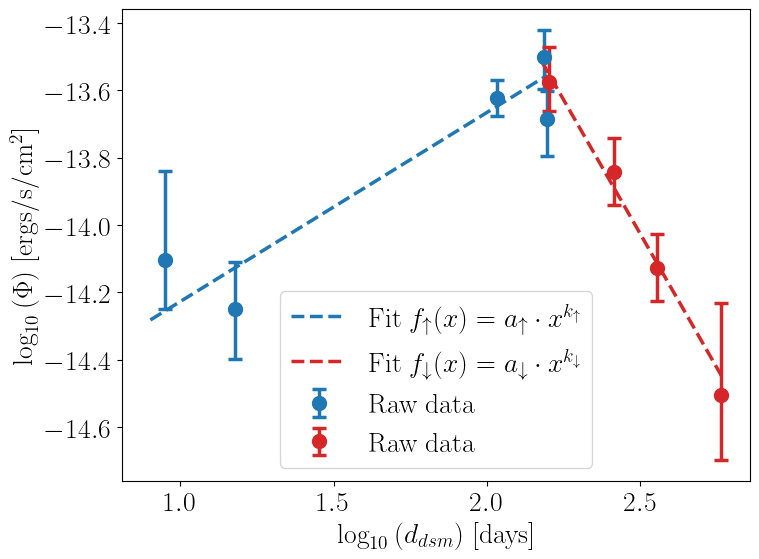

In [320]:
# Function for reading file
x,y,y_max,y_min = get_data()

y_err = np.vstack((y_min,y_max)).reshape(2,len(y))

# !!! Mean error, since sigma in curve_fit can't handle asymmetric errors!!!
er_y = np.mean((y_min,y_max),axis=0)


# Splitting data for up slope
up_idx = 5
x_up = x[:up_idx]; y_up = y[:up_idx];er_y_up = er_y[:up_idx]
y_err_up = y_err[:,:up_idx] 

'''----------- UP SLOPE -------------- '''

# Finding parameters with curve_fit
popt, pcov = curve_fit(fit_powerlaw,x_up,y_up,sigma = er_y_up)
a_fit = popt[0]; k_fit = popt[1] 

errors = (np.sqrt(np.diag(pcov)))

print(f'a_up = {a_fit:.3f} ± {errors[0]:.3f} \nk_up = {k_fit:.3f} ± {errors[1]:.3f}')


# Plotting the result
plt.figure(figsize=(8,6))

x_gen1 = np.linspace(np.min(x_up)*0.95,np.max(x_up),10000)
y_gen1 = fit_powerlaw(x_gen1,a_fit,k_fit)

plt.errorbar(x_up,y_up, yerr=y_err_up,linestyle = '',marker = 'o',label = 'Raw data',capsize=5,markersize = 10,color = 'tab:blue',lw = 2.5, capthick=2.5)
plt.plot(x_gen1,y_gen1,label = 'Fit $f_{\\uparrow}(x) = a_{\\uparrow}\\cdot x^{k_{\\uparrow}}$',lw = 2.5,color = 'tab:blue',ls = 'dashed')


'''----------- DOWN SLOPE -------------- '''

# Splitting data for down slope
x_down = x[up_idx:]; y_down = y[up_idx:];er_y_down = er_y[up_idx:]; y_err_down = y_err[:,up_idx:] 

# Finding parameters with curve_fit
popt, pcov = curve_fit(fit_powerlaw,x_down,y_down,sigma = er_y_down)
a_fit = popt[0]; k_fit = popt[1] 

errors = (np.sqrt(np.diag(pcov)))

print(f'a_down = {a_fit:.3f} ± {errors[0]:.3f} \nk_down = {k_fit:.3f} ± {errors[1]:.3f}')


# Plotting the result
x_gen2 = np.linspace(np.min(x_down)*0.99,np.max(x_down),10000); y_gen2 = fit_powerlaw(x_gen2,a_fit,k_fit)

plt.errorbar(x_down,y_down,yerr=y_err_down, linestyle = '',marker = 'o',label = 'Raw data',capsize=5,markersize = 10,color = 'tab:red',lw = 2.5, capthick=2.5)

plt.plot(x_gen2,y_gen2,label = 'Fit $f_{\\downarrow}(x) = a_{\\downarrow}\\cdot x^{k_\\downarrow}$',lw = 2.5,color = 'tab:red',ls = 'dashed')


plt.legend()

plt.xlabel('$\\log_{10}{(d_{dsm})}$ [days]')
plt.ylabel('$\\log_{10}{(\\Phi)}$ [ergs/s/cm$^2$]')

plt.tight_layout()
plt.savefig('light_join.pdf')


a_up = -14.788 ± 0.273 
k_up = 0.561 ± 0.136
a_down = -10.045 ± 0.361 
k_down = -1.592 ± 0.149


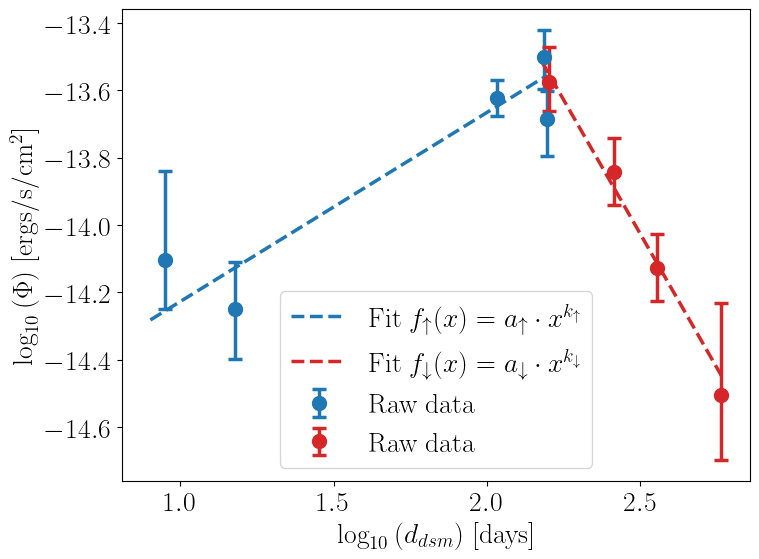

In [ ]:
# Function for reading file
x,y,y_max,y_min = get_data()

y_err = np.vstack((y_min,y_max)).reshape(2,len(y))
er_y = np.mean((y_min,y_max),axis=0)

up_idx = 5
x_up = x[:up_idx]; y_up = y[:up_idx];er_y_up = er_y[:up_idx]
y_err_up = y_err[:,:up_idx] 


#plt.figure(figsize=(8,6))

#plt.plot(10**x,y,'o')
plt.figure(figsize=(8,6))


popt, pcov = curve_fit(fit_powerlaw,x_up,y_up,sigma = er_y_up)
a_fit = popt[0]; k_fit = popt[1] 

errors = (np.sqrt(np.diag(pcov)))

print(f'a_up = {a_fit:.3f} ± {errors[0]:.3f} \nk_up = {k_fit:.3f} ± {errors[1]:.3f}')

x_gen1 = np.linspace(np.min(x_up)*0.95,np.max(x_up),10000); y_gen1 = fit_powerlaw(x_gen1,a_fit,k_fit)
#for i in range(ln(y))
plt.errorbar(x_up,y_up, yerr=y_err_up,linestyle = '',marker = 'o',label = 'Raw data',capsize=5,markersize = 10,color = 'tab:blue',lw = 2.5, capthick=2.5)
plt.plot(x_gen1,y_gen1,label = 'Fit $f_{\\uparrow}(x) = a_{\\uparrow}\\cdot x^{k_{\\uparrow}}$',lw = 2.5,color = 'tab:blue',ls = 'dashed')



x_down = x[up_idx:]; y_down = y[up_idx:];er_y_down = er_y[up_idx:]; y_err_down = y_err[:,up_idx:] 


popt, pcov = curve_fit(fit_powerlaw,x_down,y_down,sigma = er_y_down)
a_fit = popt[0]; k_fit = popt[1] 

errors = (np.sqrt(np.diag(pcov)))

print(f'a_down = {a_fit:.3f} ± {errors[0]:.3f} \nk_down = {k_fit:.3f} ± {errors[1]:.3f}')

x_gen2 = np.linspace(np.min(x_down)*0.99,np.max(x_down),10000); y_gen2 = fit_powerlaw(x_gen2,a_fit,k_fit)
#for i in range(ln(y))
plt.errorbar(x_down,y_down,yerr=y_err_down, linestyle = '',marker = 'o',label = 'Raw data',capsize=5,markersize = 10,color = 'tab:red',lw = 2.5, capthick=2.5)
plt.plot(x_gen2,y_gen2,label = 'Fit $f_{\\downarrow}(x) = a_{\\downarrow}\\cdot x^{k_\\downarrow}$',lw = 2.5,color = 'tab:red',ls = 'dashed')


plt.legend()
#plt.errorbar(x,y,yerr = [y_min,y_max], linestyle = '',marker = 'o',label = 'Raw data',capsize=5)
plt.xlabel('$\\log_{10}{(d_{dsm})}$ [days]')
plt.ylabel('$\\log_{10}{(\\Phi)}$ [ergs/s/cm$^2$]')
#plt.yscale('log')
#plt.xscale('log')
plt.tight_layout()
plt.savefig('light_join.pdf')


In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as pl
import math as m
def fit_power_law(x,a,b):
    return a*x**b
###Read in the data:
data=np.genfromtxt('temp.txt',delimiter=',',names=True)
#Note, to use column1 with column heading 'column1': data['column1']

###Fit the data:
popt, pcov = curve_fit(fit_power_law,data['x'],data['y'],sigma=data['y_err']),initial_guess, bounds=param_bounds)
print('Fit: %s x^%s ' %(popt[0],popt[1]))
print('Sigma: a=%s, b=%s' %(m.sqrt(pcov[0,0]),m.sqrt(pcov[1,1])))
###Plot:

pl.figure()
ax=pl.subplot(111)
plotx=np.arange(data['x'][0],data['x'][len(data['x'])-1]+1,(data['x']
[len(data['x'])-1]+1-data['x'][0])/20.)
#ax.errorbar(data['x'],data['y'],yerr=None,
xerr=None,linestyle='none',marker='o',color='b')
ax.errorbar(data['x'],data['y'],yerr=data['y_err']*2,linestyle='none',marker='o',
mfc='red',
mec='green',ms=10,mew=3,ecolor='blue',capsize=5,elinewidth=4) # where mfc,
mec, ms and mew are aliases for the longer property names, markerfacecolor,
markeredgecolor, markersize and markeredgewidth and ecolor is the color of the
errorbars, capsize is the size of the error bar caps, elinewidth is the width of
hte line of the errorbars
ax.plot(plotx,fit_power_law(plotx,popt[0],popt[1]))
ax.set_yscale('log',nonposy='clip')
ax.set_xscale('log',nonposx='clip')
pl.xlabel('Time since Explosion (Arbitrary Units)')
pl.ylabel('Radio Luminosity (Arbitrary Units)')
pl.show()


/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_4927/2599053156.py:15: RuntimeWarning: overflow encountered in exp
  y[i] = a * (x[i]**k) * np.exp(-nH * sigma)


a = 0.00016739048219441253 ± 6.106642349958208e-06 
 k = -1.099 ± 0.045253858640026984 
 nh = 6.694249826391361e+20 ± 7.2158073863676944e+19


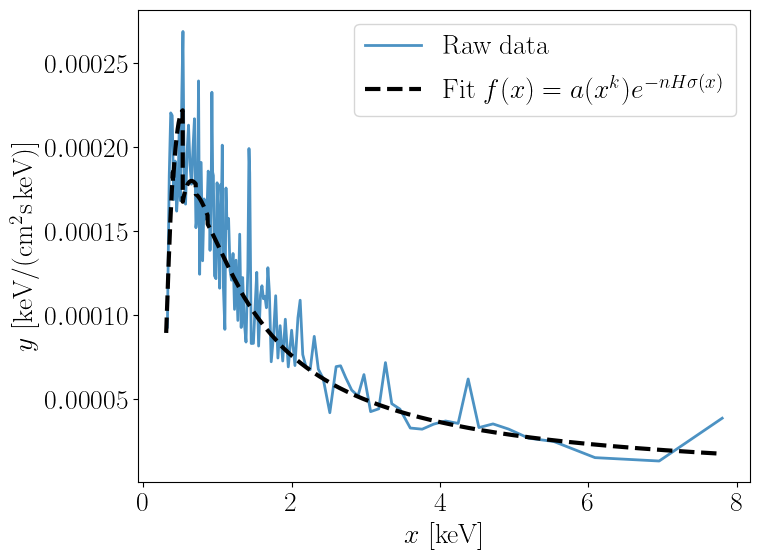

In [12]:
z = 0
#z = 3.038

x, y, er_y = get_data(z)
x_gen = np.linspace(np.min(x)*0.95,np.max(x),10000)


if z == 0:
    color = 'tab:blue'
else: 
    color = 'tab:red'


popt, pcov = curve_fit(f_power,x,y,sigma = er_y)
a_fit = popt[0]; k_fit = popt[1];nH_fit = popt[2] 

errors = (np.sqrt(np.diag(pcov)))

plt.figure(figsize = (8,6))

y_gen = f_power(x_gen,a_fit,k_fit,nH_fit)
plt.plot(x,y,label='Raw data',lw = 2,alpha = 0.8,color = color)
plt.plot(x_gen,y_gen,'k--',label = 'Fit $f(x) = a(x^k)e^{-nH\\sigma(x)}$',lw = 3)
plt.xlabel('$x$ [keV]')
plt.ylabel('$y$ [keV/(cm$^2$s\\,keV)]')
plt.legend()

print(f'a = {a_fit} ± {errors[0]} \n k = {k_fit:.3f} ± {errors[1]} \n nh = {nH_fit*1e24} ± {errors[2]*1e24}')

plt.tight_layout()
plt.savefig(f'fitted_data_z_{z}.pdf')

[0.00055563 0.04550844 0.04963112]
a = 0.012972453060483278 
 k = -1.052 
 nh = 1.182060273078477e+25


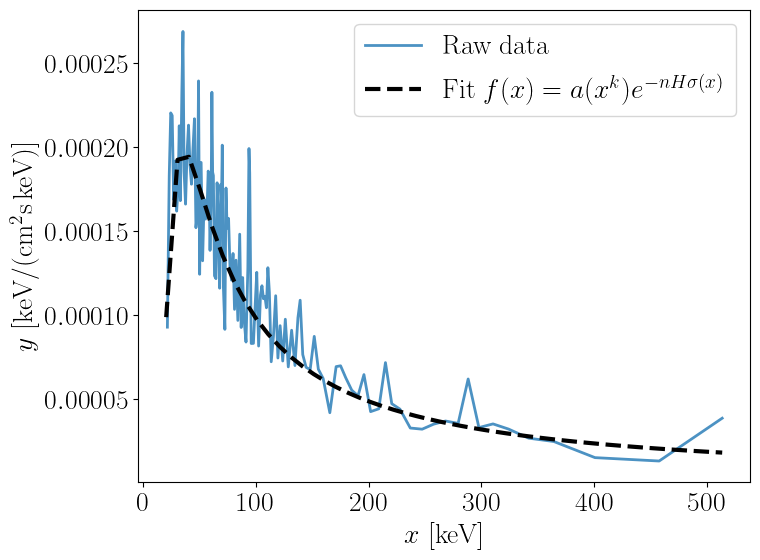

In [152]:
z = 3.038
#z = 0
x_z = x * (z + 1)

y = y

x_gen_z = (z + 1) * x_gen
popt_z, pcov_z = curve_fit(f_power,x_z,y,sigma = er_y)
a_fit_z = popt_z[0]; k_fit_z = popt_z[1];nH_fit_z = popt_z[2] 

plt.figure(figsize = (8,6))

print(np.sqrt(np.diag(pcov)))

#x_gen = np.linspace(np.min(x)*0.95,np.max(x),10000)
y_gen = f_power(x_gen_z,a_fit_z,k_fit_z,nH_fit_z)
plt.plot(x_z,y,label='Raw data',lw = 2,alpha = 0.8)
plt.plot(x_gen_z,y_gen,'k--',label = 'Fit $f(x) = a(x^k)e^{-nH\\sigma(x)}$',lw = 3)
plt.xlabel('$x$ [keV]')
plt.ylabel('$y$ [keV/(cm$^2$s\\,keV)]')
plt.legend()

print(f'a = {a_fit_z} \n k = {k_fit_z:.3f} \n nh = {nH_fit_z*1e24}')
plt.tight_layout()
#plt.savefig('fitted_data.pdf')


For the 3 task. It should just be to check the value of the Milky Way using the NASA website. Maybe I can do some type of map. Look both in the Milky way direction and the direction perpendicular to the Milky Way.

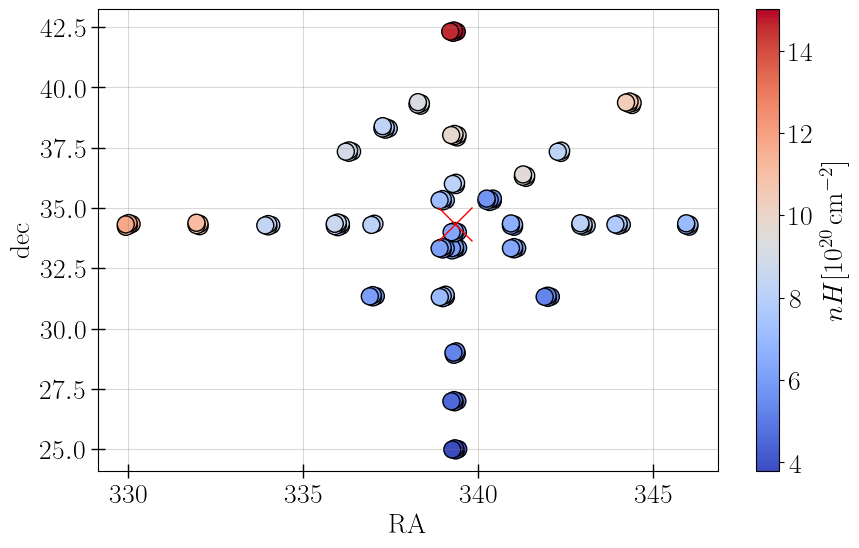

In [ ]:
data_2 = pd.read_excel('Book1.xlsx')
data_2 = np.array(data_2)

RA = data_2[:,0];dec = data_2[:,1];nH = data_2[:,3] * 1e-20

size = 10
plt.figure(figsize=(size,int(10 * size / 15)))
plt.grid(color='grey',alpha =0.3)
plt.scatter(RA,dec,c = nH,cmap='coolwarm',edgecolors='k',s = size * 15)
plt.plot(339.3331,34.3316,'rx',ms = 25)
plt.colorbar(label = '$nH [10^{20}\\,\\mathrm{cm}^{-2}]$')
#ax = plt.gca()
#ax.set_facecolor('gainsboro')
plt.xlabel('RA')
plt.ylabel('dec')
plt.tick_params(axis='both',direction='inout', length=10, width=1, colors='black')